# Notebook 3 — Fine-tuning con LoRA: BERT / clinical-BERT / mT5

Skeleton único y reutilizable para los tres modelos. Para cambiar de modelo, se edita
**solo la celda de configuración** (`MODEL_KEY`) — el resto del notebook se adapta solo.

**Cambios importantes respecto al ejemplo visto en clase:**
- `target_modules` depende de la arquitectura: BERT/RoBERTa usan `query`/`value`. mT5 (arquitectura T5)
  usa `q`/`v`.
- `task_type`: Para BERT/clinical-BERT es `TOKEN_CLS`
  (clasificación de tokens / NER) y mT5 es `SEQ_2_SEQ_LM`.

## 1. Setup e imports

In [19]:
try:
    from google.colab import drive
    drive.mount("/content/drive")

except ImportError:
    SPLITS_DIR = "."

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:


import numpy as np
import torch
import random
from pathlib import Path
from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForSeq2SeqLM,
    DataCollatorForTokenClassification,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Seq2SeqTrainingArguments,
    Trainer,
    Seq2SeqTrainer,
)
from peft import LoraConfig, get_peft_model, TaskType

random.seed(42)

SPLITS_DIR = Path("/content/drive/MyDrive/TopicosIA/Proyecto-Salud/M1/distemist_final")


## 2. Configuración — ÚNICO LUGAR QUE CAMBIA ENTRE MODELOS

Cambien `MODEL_KEY` a `"bert"`, `"clinical_bert"` o `"mt5"` y vuelvan a correr el notebook
completo. Ajusten los nombres de checkpoint según lo que decidieron usar (recuerden: si el
texto de DisTEMIST está en español, el "BERT clínico" debe ser un modelo clínico en
**español**, no BioClinicalBERT que es en inglés/MIMIC — como vimos antes).


In [21]:
MODEL_KEY = "bert"  # "bert" | "clinical_bert" | "mt5"

MODEL_REGISTRY = {
    "bert": {
        "checkpoint": "dccuchile/bert-base-spanish-wwm-cased",
        "arch": "token_classification",
        "lora_target_modules": ["query", "value"],
        "lora_task_type": TaskType.TOKEN_CLS,
        "dataset": "distemist_bert_format",
    },
    "clinical_bert": {
        "checkpoint": "PlanTL-GOB-ES/roberta-base-biomedical-clinical-es",
        "arch": "token_classification",
        "lora_target_modules": ["query", "value"],
        "lora_task_type": TaskType.TOKEN_CLS,
        "dataset": "distemist_bert_format",
    },
    "mt5": {
        "checkpoint": "google/mt5-small",
        "arch": "seq2seq",
        "lora_target_modules": ["q", "v"],
        "lora_task_type": TaskType.SEQ_2_SEQ_LM,
        "dataset": "distemist_mt5_format",
    },
}

cfg = MODEL_REGISTRY[MODEL_KEY]
print(cfg)


{'checkpoint': 'dccuchile/bert-base-spanish-wwm-cased', 'arch': 'token_classification', 'lora_target_modules': ['query', 'value'], 'lora_task_type': <TaskType.TOKEN_CLS: 'TOKEN_CLS'>, 'dataset': 'distemist_bert_format'}


Login W&B

In [22]:
! wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: laneriop (medical-research-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 3. Cargar datos procesados del Notebook 1

Mismo split para los tres modelos — solo cambia el *formato* según la arquitectura.


In [23]:
if cfg["arch"] == "token_classification":
    raw_ds = load_from_disk(str(SPLITS_DIR / "distemist_bert_format"))
    label_list = ["O", "B-ENFERMEDAD", "I-ENFERMEDAD"]
    label2id = {l: i for i, l in enumerate(label_list)}
    id2label = {i: l for i, l in enumerate(label_list)}
else:
    raw_ds = load_from_disk(str(SPLITS_DIR / "distemist_mt5_format"))

print(raw_ds)


DatasetDict({
    train: Dataset({
        features: ['doc_id', 'tokens', 'ner_tags'],
        num_rows: 55
    })
    dev: Dataset({
        features: ['doc_id', 'tokens', 'ner_tags'],
        num_rows: 6
    })
    test: Dataset({
        features: ['doc_id', 'tokens', 'ner_tags'],
        num_rows: 10
    })
})


In [24]:
print(raw_ds["dev"].column_names)
print("doc_id" in raw_ds["dev"].column_names)  # True/False directo

# y confirma que además tiene contenido real, no solo que la columna existe
print(raw_ds["dev"]["doc_id"][:5])

['doc_id', 'tokens', 'ner_tags']
True
['es-S0210-48062006000700010-1_chunk0', 'es-S0210-48062006000700010-1_chunk1', 'es-S0210-48062009000600018-1_chunk0', 'es-S0210-48062009000600018-1_chunk1', 'es-S1135-76062010000200006-1_chunk0']


## 4. Tokenizador y modelo base

In [25]:
tokenizer = AutoTokenizer.from_pretrained(cfg["checkpoint"])

if cfg["arch"] == "token_classification":
    model = AutoModelForTokenClassification.from_pretrained(
        cfg["checkpoint"],
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
    )
else:
    model = AutoModelForSeq2SeqLM.from_pretrained(cfg["checkpoint"])

model


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

## 5. Tokenización / preprocesamiento según arquitectura

In [26]:
def tokenize_and_align_labels_bert(example):
    tokenized = tokenizer(example["tokens"], truncation=True, is_split_into_words=True)
    word_ids = tokenized.word_ids()
    labels = []
    previous_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)  # ignorado en la loss
        elif word_idx != previous_word_idx:
            labels.append(label2id[example["ner_tags"][word_idx]])
        else:
            # subpalabra dentro del mismo token: mismo tag pero como I- si era B-
            tag = example["ner_tags"][word_idx]
            tag = tag.replace("B-", "I-")
            labels.append(label2id[tag])
        previous_word_idx = word_idx
    tokenized["labels"] = labels
    return tokenized


def tokenize_mt5(example):
    model_inputs = tokenizer(example["input_text"], truncation=True, max_length=512)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(example["target_text"], truncation=True, max_length=128)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


if cfg["arch"] == "token_classification":
    tokenized_ds = raw_ds.map(tokenize_and_align_labels_bert, batched=False)
    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
else:
    tokenized_ds = raw_ds.map(tokenize_mt5, batched=False)
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

tokenized_ds


DatasetDict({
    train: Dataset({
        features: ['doc_id', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 55
    })
    dev: Dataset({
        features: ['doc_id', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 6
    })
    test: Dataset({
        features: ['doc_id', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 10
    })
})

## 6. Métricas comparables entre los 3 modelos

Como discutimos: BERT hace clasificación de tokens y mT5 genera texto libre, así que no se
puede comparar con la misma función "cruda". La solución es reducir la salida de **ambas**
arquitecturas al mismo formato común — **el conjunto de nombres de enfermedad detectados por
documento** — y calcular precisión/recall/F1 sobre ese conjunto. Así el número final es
comparable entre modelos aunque el mecanismo interno sea distinto.


In [27]:
# --- 1. Helpers de bajo nivel: texto/BIO -> conjunto de entidades por ejemplo ---

def strip_chunk_suffix(doc_id):
    return __import__("re").sub(r"_chunk\d+$", "", doc_id)


def bio_to_entity_set(tokens, tags):
    entities, current = [], []
    for tok, tag in zip(tokens, tags):
        if tag == "B-ENFERMEDAD":
            if current:
                entities.append(" ".join(current))
            current = [tok]
        elif tag == "I-ENFERMEDAD" and current:
            current.append(tok)
        else:
            if current:
                entities.append(" ".join(current))
            current = []
    if current:
        entities.append(" ".join(current))
    return set(e.lower().strip() for e in entities)


def mt5_output_to_entity_set(generated_text):
    if generated_text.strip().lower() == "ninguna":
        return set()
    parts = generated_text.split("[SEP]")
    return set(p.lower().strip() for p in parts if p.strip())


# --- 2. Agregación por documento original (junta los chunks de un mismo caso) ---

def aggregate_entities_by_original_doc(doc_ids, entity_sets):
    grouped = {}
    for doc_id, ents in zip(doc_ids, entity_sets):
        orig_id = strip_chunk_suffix(doc_id)
        grouped.setdefault(orig_id, set()).update(ents)
    return grouped


# --- 3. Métrica: micro-F1 sumando tp/fp/fn por documento (no un set global) ---

def entity_set_prf1(true_entities, pred_entities):
    tp = len(true_entities & pred_entities)
    fp = len(pred_entities - true_entities)
    fn = len(true_entities - pred_entities)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}


def micro_prf1_by_doc(true_by_doc, pred_by_doc):
    """
    Suma tp/fp/fn documento por documento (evita colisiones de nombres de
    entidades entre pacientes distintos) y calcula precision/recall/F1 al final,
    sobre el corpus completo ya reagrupado.
    """
    tp = fp = fn = 0
    all_doc_ids = set(true_by_doc) | set(pred_by_doc)
    for doc_id in all_doc_ids:
        true_ents = true_by_doc.get(doc_id, set())
        pred_ents = pred_by_doc.get(doc_id, set())
        tp += len(true_ents & pred_ents)
        fp += len(pred_ents - true_ents)
        fn += len(true_ents - pred_ents)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}


# --- 4. compute_metrics por arquitectura, ahora con agregación por documento ---

def compute_metrics_bert(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    doc_ids = raw_ds["dev"]["doc_id"]
    tokens_col = raw_ds["dev"]["tokens"]

    pred_sets, true_sets = [], []
    for pred_seq, label_seq, tokens in zip(predictions, labels, tokens_col):
        pred_tags = [id2label[p] for p, l in zip(pred_seq, label_seq) if l != -100]
        true_tags = [id2label[l] for l in label_seq if l != -100]
        pred_sets.append(bio_to_entity_set(tokens[: len(pred_tags)], pred_tags))
        true_sets.append(bio_to_entity_set(tokens[: len(true_tags)], true_tags))

    pred_by_doc = aggregate_entities_by_original_doc(doc_ids, pred_sets)
    true_by_doc = aggregate_entities_by_original_doc(doc_ids, true_sets)

    return micro_prf1_by_doc(true_by_doc, pred_by_doc)


def compute_metrics_mt5(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    doc_ids = raw_ds["dev"]["doc_id"]

    pred_sets = [mt5_output_to_entity_set(t) for t in decoded_preds]
    true_sets = [mt5_output_to_entity_set(t) for t in decoded_labels]

    pred_by_doc = aggregate_entities_by_original_doc(doc_ids, pred_sets)
    true_by_doc = aggregate_entities_by_original_doc(doc_ids, true_sets)

    return micro_prf1_by_doc(true_by_doc, pred_by_doc)


compute_metrics = compute_metrics_bert if cfg["arch"] == "token_classification" else compute_metrics_mt5

## 7. Baseline (antes de fine-tuning)

Evalúan el modelo base (sin LoRA) para tener el número de referencia con el que van a comparar
el modelo fine-tuneado — necesario para poder afirmar "el fine-tuning mejoró X puntos de F1"
con respaldo real, no solo asumido.


In [28]:
config = {
    "model": cfg["checkpoint"],
    "arch": cfg["arch"],
    "dataset": cfg["dataset"],
}

In [29]:
import wandb

wandb.init(
    # Team name
    entity="medical-research-ai",
    # Project
    project="M1-fine-tuning",
    # Name of the run (nombre del modelo )
    name=f"baseline-{MODEL_KEY}",
    # Track hyperparameters and run metadata.
    config=config
)

In [30]:
baseline_args_kwargs = dict(
    output_dir="./baseline-eval",
    per_device_eval_batch_size=4,
    report_to="wandb",
)

if cfg["arch"] == "token_classification":
    baseline_args = TrainingArguments(**baseline_args_kwargs)
    baseline_trainer = Trainer(
        model=model,
        args=baseline_args,
        eval_dataset=tokenized_ds["dev"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
else:
    baseline_args = Seq2SeqTrainingArguments(**baseline_args_kwargs, predict_with_generate=True)
    baseline_trainer = Seq2SeqTrainer(
        model=model,
        args=baseline_args,
        eval_dataset=tokenized_ds["dev"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

baseline_metrics = baseline_trainer.evaluate()
print("Métricas BASELINE (sin fine-tuning):", baseline_metrics)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Precision,Recall,F1
No log,1.196368,0,0.016129,0.032258,0.021505


Métricas BASELINE (sin fine-tuning): {'eval_loss': 1.196367621421814, 'eval_precision': 0.016129032258064516, 'eval_recall': 0.03225806451612903, 'eval_f1': 0.02150537634408602}


In [31]:
wandb.finish()

eval/f1,▁
eval/loss,▁
eval/model_preparation_time,▁
eval/precision,▁
eval/recall,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/epoch,▁
train/global_step,▁
eval/f1,0.02151


## 8. Configuración de LoRA (corregida por arquitectura)

In [32]:
config = {
    "model": cfg["checkpoint"],
    "arch": cfg["arch"],
    "dataset": cfg["dataset"],
}

In [33]:
wandb.init(
    # Team name
    entity="medical-research-ai",
    # Project
    project="M1-fine-tuning",
    # Name of the run (nombre del modelo )
    name= f"fine-tuned-{MODEL_KEY}",
    # Track hyperparameters and run metadata.
    config=config
)

In [34]:
!pip install --upgrade torchao

In [35]:
lora_config = LoraConfig(
    r=8,                                    # rank de las matrices nuevas
    lora_alpha=16,                          # regla común: alpha = 2 x rank
    target_modules=cfg["lora_target_modules"],
    lora_dropout=0.05,
    task_type=cfg["lora_task_type"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 297,219 || all params: 109,559,814 || trainable%: 0.2713


## 9. Argumentos de entrenamiento

In [36]:
train_args_kwargs = dict(
    output_dir=f"./lora-out-{MODEL_KEY}",
    learning_rate=2e-4,
    num_train_epochs=10,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=5,
    report_to="wandb",
    fp16=torch.cuda.is_available(),
)

if cfg["arch"] == "token_classification":
    train_args = TrainingArguments(**train_args_kwargs)
    trainer = Trainer(
        model=model,
        args=train_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["dev"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
else:
    train_args = Seq2SeqTrainingArguments(**train_args_kwargs, predict_with_generate=True)
    trainer = Seq2SeqTrainer(
        model=model,
        args=train_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["dev"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.570505,0.628596,0.000000,0.000000,0.000000
2,0.342515,0.471335,0.000000,0.000000,0.000000
3,0.259440,0.434065,0.000000,0.000000,0.000000
4,0.254954,0.475607,0.000000,0.000000,0.000000
5,0.240273,0.442252,0.000000,0.000000,0.000000
6,0.153477,0.461805,0.666667,0.064516,0.117647
7,0.147302,0.419365,0.636364,0.225806,0.333333
8,0.145526,0.438171,0.600000,0.193548,0.292683
9,0.117967,0.476344,0.600000,0.193548,0.292683
10,0.152200,0.459225,0.545455,0.193548,0.285714


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

TrainOutput(global_step=280, training_loss=0.2654124826192856, metrics={'train_runtime': 2525.265, 'train_samples_per_second': 0.218, 'train_steps_per_second': 0.111, 'total_flos': 109894044747636.0, 'train_loss': 0.2654124826192856, 'epoch': 10.0})

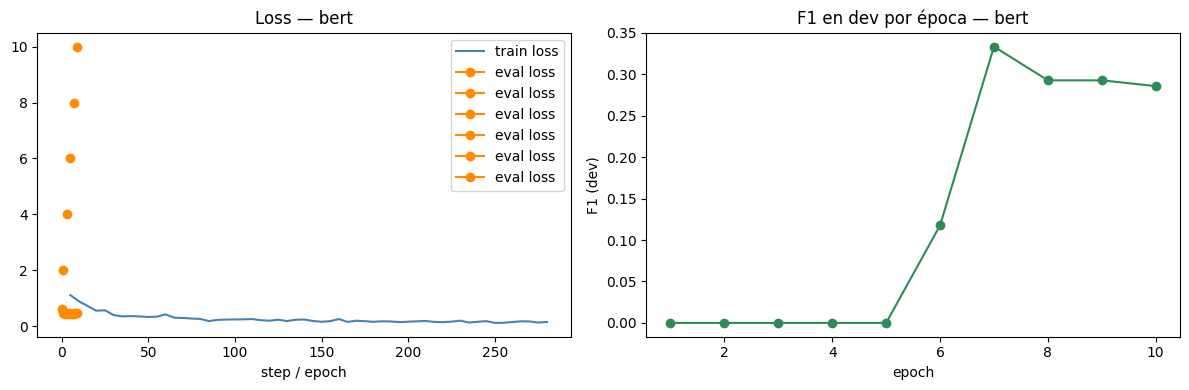

In [37]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_loss  = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
eval_f1    = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(*zip(*train_loss), label="train loss", color="steelblue")
axes[0].plot(*[e for e,_ in eval_loss], [l for _,l in eval_loss], label="eval loss", color="darkorange", marker="o")
axes[0].set_xlabel("step / epoch"); axes[0].set_title(f"Loss — {MODEL_KEY}"); axes[0].legend()

axes[1].plot(*zip(*eval_f1), color="seagreen", marker="o")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("F1 (dev)"); axes[1].set_title(f"F1 en dev por época — {MODEL_KEY}")

plt.tight_layout()
plt.savefig(f"eval_curves_{MODEL_KEY}.png", dpi=150)
plt.show()

## 10. Evaluación final en test

In [38]:
final_metrics = trainer.evaluate(tokenized_ds["test"])
print(f"Métricas FINE-TUNEADO ({MODEL_KEY}) en test:", final_metrics)

print("\n--- Comparación ---")
print("Baseline (dev):     ", baseline_metrics)
print("Fine-tuneado (test):", final_metrics)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Precision,Recall,F1
0.152200,0.241377,10,0.363636,0.125000,0.186047


Métricas FINE-TUNEADO (bert) en test: {'eval_loss': 0.24137668311595917, 'eval_precision': 0.36363636363636365, 'eval_recall': 0.125, 'eval_f1': 0.18604651162790697}

--- Comparación ---
Baseline (dev):      {'eval_loss': 1.196367621421814, 'eval_precision': 0.016129032258064516, 'eval_recall': 0.03225806451612903, 'eval_f1': 0.02150537634408602}
Fine-tuneado (test): {'eval_loss': 0.24137668311595917, 'eval_precision': 0.36363636363636365, 'eval_recall': 0.125, 'eval_f1': 0.18604651162790697}


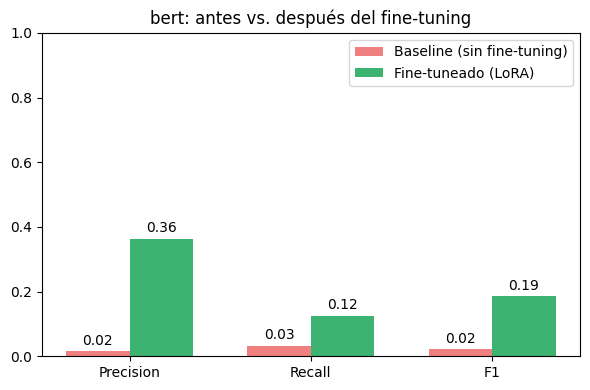

In [39]:
import numpy as np

metrics_names = ["precision", "recall", "f1"]
baseline_vals = [baseline_metrics[f"eval_{m}"] for m in metrics_names]
finetuned_vals = [final_metrics[f"eval_{m}"] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, baseline_vals, width, label="Baseline (sin fine-tuning)", color="lightcoral")
ax.bar(x + width/2, finetuned_vals, width, label="Fine-tuneado (LoRA)", color="mediumseagreen")

ax.set_xticks(x); ax.set_xticklabels(["Precision", "Recall", "F1"])
ax.set_ylim(0, 1)
ax.set_title(f"{MODEL_KEY}: antes vs. después del fine-tuning")
for i, v in enumerate(baseline_vals): ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha="center")
for i, v in enumerate(finetuned_vals): ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha="center")
ax.legend()
plt.tight_layout()
plt.savefig(f"baseline_vs_finetuned_{MODEL_KEY}.png", dpi=150)
plt.show()

In [40]:
wandb.finish()

eval/f1,▁▁▁▁▁▃█▇▇▇▅
eval/loss,█▅▄▅▅▅▄▅▅▅▁
eval/precision,▁▁▁▁▁██▇▇▇▅
eval/recall,▁▁▁▁▁▃█▇▇▇▅
eval/runtime,▁▁▂▂▂▁▃▃▃▃█
eval/samples_per_second,██▃▅▃█▃▃▃▂▁
eval/steps_per_second,██▄▅▄█▄▄▄▃▁
train/epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
train/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train/grad_norm,█▇▃▃▂▂▃▂▂▂▂▃▁▂▁▁▁▂▂▂▂▁▂▂▂▅▁▂▁▁▁▁▂▁▂▃▂▁▄▂
+2,...


## 11. Visualizar un ejemplo: antes vs. después del fine-tuning

Toman un ejemplo del set de test y comparan la predicción del modelo base contra la del
modelo fine-tuneado con LoRA, lado a lado.


In [41]:
import torch
from IPython.display import HTML, display
from transformers import AutoModelForTokenClassification

example = raw_ds["test"][0]

if cfg["arch"] == "token_classification":

    def predict_word_level(pred_model, tokens):
        """Predice tag por SUBTOKEN y lo colapsa a nivel de PALABRA
        (se queda con la predicción de la primera subpalabra de cada palabra,
        igual que se hizo al armar los labels de entrenamiento)."""
        inputs = tokenizer(tokens, is_split_into_words=True,
                            return_tensors="pt", truncation=True)
        word_ids = inputs.word_ids(batch_index=0)
        with torch.no_grad():
            logits = pred_model(**inputs).logits
        pred_ids = logits.argmax(dim=-1)[0].tolist()

        word_preds, seen = [], set()
        for idx, wid in zip(pred_ids, word_ids):
            if wid is None or wid in seen:
                continue
            word_preds.append(id2label[idx])
            seen.add(wid)
        return word_preds


    base_model_raw = AutoModelForTokenClassification.from_pretrained(
        cfg["checkpoint"], num_labels=len(label_list),
        id2label=id2label, label2id=label2id
    )
    base_model_raw.eval()

    tokens = example["tokens"]
    true_tags = example["ner_tags"]
    baseline_tags = predict_word_level(base_model_raw, tokens)
    finetuned_tags = predict_word_level(model, tokens)

    assert len(tokens) == len(true_tags) == len(baseline_tags) == len(finetuned_tags), "Algo sigue sin alinear — revisar tokenización"

    def is_entity(tag):
        return tag.startswith("B-") or tag.startswith("I-")

    def render_row(label, tokens, tags, true_tags):

        html_output = f"<div style='margin-bottom:6px; max-width: 700px; display: flex; flex-wrap: wrap;'><b>{label}:</b><br>"
        for tok, tag, true in zip(tokens, tags, true_tags):
            t_ent, p_ent = is_entity(true), is_entity(tag)
            if t_ent and p_ent:
                color = "#b6e3a5"
            elif p_ent and not t_ent:
                color = "#f4a3a3"
            elif t_ent and not p_ent:
                color = "#f7c98d"
            else:
                color = "transparent"

            html_output += (f'<span style="background-color:{color};padding:1px 4px;'
                             f'border-radius:3px;margin-right:2px; display: inline-block; white-space: nowrap;" title="{tag}">{tok}</span>')
        html_output += "</div>"
        return html_output

    legend = ("<div style='margin-bottom:8px;font-size:0.9em'>"
              "<span style='background-color:#b6e3a5;padding:1px 6px;border-radius:3px'>Acierto</span> "
              "<span style='background-color:#f4a3a3;padding:1px 6px;border-radius:3px'>Falso positivo</span> "
              "<span style='background-color:#f7c98d;padding:1px 6px;border-radius:3px'>Se le escapó (FN)</span>"
              "</div>")

    html_out = legend
    html_out += render_row("Referencia (ground truth)", tokens, true_tags, true_tags)
    html_out += render_row("Baseline (sin fine-tuning)", tokens, baseline_tags, true_tags)
    html_out += render_row(f"Fine-tuneado ({MODEL_KEY} + LoRA)", tokens, finetuned_tags, true_tags)

    display(HTML(html_out))

else:
    inputs = tokenizer(example["input_text"], return_tensors="pt")
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=64)
    print("Predicción (fine-tuneado):", tokenizer.decode(output_ids[0], skip_special_tokens=True))
    print("Referencia (ground truth):", example["target_text"])


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 12. Guardar modelo

Con LoRA solo se guardan los pesos del adaptador (mucho más liviano que el modelo completo).


In [42]:
import json

OUTPUT_DIR = Path("/content/drive/MyDrive/TopicosIA/Proyecto-Salud/M1/outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

summary = {
    "model_key": MODEL_KEY,
    "checkpoint": cfg["checkpoint"],
    "baseline": {m: baseline_metrics[f"eval_{m}"] for m in metrics_names},
    "finetuned": {m: final_metrics[f"eval_{m}"] for m in metrics_names},
}
with open(OUTPUT_DIR / f"results_{MODEL_KEY}.json", "w") as f:
    json.dump(summary, f, indent=2)

In [43]:
save_dir = f"./saved-models/{MODEL_KEY}-distemist-lora"
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Modelo guardado en: {save_dir}")


Modelo guardado en: ./saved-models/bert-distemist-lora
